In [1]:
!pip install requests pandas tqdm openfoodfacts -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 944.4 kB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
import json
import time
import os
from tqdm import tqdm
from IPython.display import display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Headers pour identifier notre scraper
HEADERS = {
    'User-Agent': 'MonProjetRecherche/1.0 (contact@example.com)',
    'Accept-Language': 'fr-FR,fr;q=0.9'
}

# URLs — définies une seule fois et ne changent plus
BASE_URL    = 'https://fr.openfoodfacts.org'
API_V2_URL  = 'https://world.openfoodfacts.org/api/v2'
API_V0_URL  = 'https://world.openfoodfacts.org/api/v0'
API_CGI_URL = 'https://world.openfoodfacts.org/cgi/search.pl'

print('✅ Dépendances chargées')

✅ Dépendances chargées


In [3]:
def make_session() -> requests.Session:
    """Crée une session avec retry automatique."""
    session = requests.Session()
    retry = Retry(
        total=5,
        backoff_factor=2,
        status_forcelist=[429, 500, 502, 503, 504]
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('https://', adapter)
    session.headers.update(HEADERS)
    return session

In [4]:
def get_product_by_barcode(barcode: str) -> dict:
    """Récupère un produit par son code-barres."""
    url = f"{API_V0_URL}/product/{barcode}.json"
    session = make_session()
    try:
        r = session.get(url, timeout=30)
        r.raise_for_status()
        data = r.json()
        if data.get('status') == 1:
            return data['product']
        else:
            print(f"Produit {barcode} non trouvé.")
            return {}
    except requests.exceptions.RequestException as e:
        print(f"Erreur réseau : {e}")
        return {}

# Test
produit = get_product_by_barcode('3017620422003')

if produit:
    print(f"Nom        : {produit.get('product_name')}")
    print(f"Marque     : {produit.get('brands')}")
    print(f"Nutri-Score: {produit.get('nutriscore_grade', '?').upper()}")
    print(f"Catégorie  : {produit.get('categories')}")
    print(f"Ingrédients: {str(produit.get('ingredients_text_fr', ''))[:150]}...")

Nom        : Nutella
Marque     : Nutella
Nutri-Score: E
Catégorie  : Petit-déjeuners,Produits à tartiner,Produits à tartiner sucrés,Pâtes à tartiner
Ingrédients: Sucre, huile de palme, NOISETTES 13%, cacao maigre 7,4%, LAIT écrémé en poudre 6,6%, LACTOSERUM en poudre, émulsifiants: lécithines [SOJA), vanilline....


In [5]:
def search_products(query: str, page: int = 1, page_size: int = 50) -> pd.DataFrame:
    """Recherche des produits par mot-clé via l'API v2."""
    session = make_session()
    url = f"{API_V2_URL}/search"
    fields = (
        'code,product_name,brands,nutriscore_grade,nova_group,'
        'ecoscore_grade,categories,ingredients_text_fr,'
        'energy-kcal_100g,fat_100g,sugars_100g,proteins_100g,salt_100g'
    )
    params = {
        'search_terms': query,
        'page': page,
        'page_size': page_size,
        'fields': fields,
        'json': 1
    }
    try:
        r = session.get(url, params=params, timeout=20)
        r.raise_for_status()
        products = r.json().get('products', [])
        return pd.DataFrame(products)
    except requests.exceptions.HTTPError as e:
        print(f"❌ Erreur HTTP (v2) : {e}")
        print("💡 Basculement sur l'endpoint alternatif (cgi/search.pl)...")
        return search_products_v1(query, page, page_size)


def search_products_v1(query: str, page: int = 1, page_size: int = 50) -> pd.DataFrame:
    """Fallback sur l'ancien endpoint /cgi/search.pl (plus stable)."""
    session = make_session()
    params = {
        'search_terms': query,
        'search_simple': 1,
        'action': 'process',
        'json': 1,
        'page': page,
        'page_size': page_size,
    }
    try:
        r = session.get(API_CGI_URL, params=params, timeout=20)
        r.raise_for_status()
        products = r.json().get('products', [])
        return pd.DataFrame(products)
    except requests.exceptions.RequestException as e:
        print(f"❌ Erreur réseau (v1) : {e}")
        return pd.DataFrame()


# Test
df_search = search_products_v1('yaourt', page_size=20)
print(f"✅ Produits trouvés : {len(df_search)}")

cols_to_show = [c for c in ['code', 'product_name', 'brands', 'nutriscore_grade'] if c in df_search.columns]
display(df_search[cols_to_show].head(10))

✅ Produits trouvés : 20


,code,product_name,brands,nutriscore_grade
0,6111242100985,,Perly,a
1,6111242100206,Yaourt nature,Jaouda,b
2,6111242100305,jaouda Cremy,jaouda,a
3,6111032001010,DANONE ASSIL BANANE,Danone,c
4,6111242103702,Yaourt Grec Muesli,Jaouda,c
5,8424893600352,kéfir 500g,Reina,c
6,6111242100930,رايبي جودة,Jaouda,e
7,6111242102002,غلال القمح,Jaouda,c
8,6111032008453,danino,Danone,c
9,6111242102781,Tendre nature,"Tendre, jouda",c


In [6]:
def scrape_category(category_slug: str, max_pages: int = 5, sleep: float = 2.0) -> pd.DataFrame:
    """
    Scrape une catégorie via l'endpoint /cgi/search.pl (plus stable).
    """
    fields = (
        'code,product_name,brands,nutriscore_grade,nova_group,'
        'categories,energy-kcal_100g,fat_100g,sugars_100g,proteins_100g,salt_100g'
    )
    all_products = []

    for page in tqdm(range(1, max_pages + 1), desc=f'Catégorie: {category_slug}'):
        params = {
            'action': 'process',
            'tagtype_0': 'categories',
            'tag_contains_0': 'contains',
            'tag_0': category_slug,
            'fields': fields,
            'page': page,
            'page_size': 50,
            'json': 1
        }
        try:
            r = requests.get(API_CGI_URL, params=params, headers=HEADERS, timeout=20)
            r.raise_for_status()
            products = r.json().get('products', [])
            if not products:
                print(f'Fin des résultats à la page {page}.')
                break
            all_products.extend(products)
            print(f'Page {page} : {len(products)} produits récupérés')
        except Exception as e:
            print(f'Erreur page {page} : {e}')
            print('Nouvelle tentative dans 10s...')
            time.sleep(10)
            continue

        time.sleep(sleep)

    return pd.DataFrame(all_products)


df_biscuits = scrape_category('biscuits-and-cakes', max_pages=3)
print(f"\n✅ {len(df_biscuits)} produits collectés")
display(df_biscuits.head(5))

Catégorie: biscuits-and-cakes:   0%|          | 0/3 [00:00<?, ?it/s]

Erreur page 1 : 503 Server Error: Service Temporarily Unavailable for url: https://world.openfoodfacts.org/cgi/search.pl?action=process&tagtype_0=categories&tag_contains_0=contains&tag_0=biscuits-and-cakes&fields=code%2Cproduct_name%2Cbrands%2Cnutriscore_grade%2Cnova_group%2Ccategories%2Cenergy-kcal_100g%2Cfat_100g%2Csugars_100g%2Cproteins_100g%2Csalt_100g&page=1&page_size=50&json=1
Nouvelle tentative dans 10s...


Catégorie: biscuits-and-cakes:  33%|███▎      | 1/3 [00:10<00:21, 10.88s/it]

Page 2 : 50 produits récupérés


Catégorie: biscuits-and-cakes:  67%|██████▋   | 2/3 [00:19<00:09,  9.68s/it]

Erreur page 3 : 503 Server Error: Service Temporarily Unavailable for url: https://world.openfoodfacts.org/cgi/search.pl?action=process&tagtype_0=categories&tag_contains_0=contains&tag_0=biscuits-and-cakes&fields=code%2Cproduct_name%2Cbrands%2Cnutriscore_grade%2Cnova_group%2Ccategories%2Cenergy-kcal_100g%2Cfat_100g%2Csugars_100g%2Cproteins_100g%2Csalt_100g&page=3&page_size=50&json=1
Nouvelle tentative dans 10s...


Catégorie: biscuits-and-cakes: 100%|██████████| 3/3 [00:30<00:00, 10.18s/it]


✅ 50 produits collectés


,brands,categories,code,energy-kcal_100g,fat_100g,nova_group,nutriscore_grade,nutrition_data,nutrition_data_prepared_per,product_name,proteins_100g,salt_100g,sugars_100g,nutriments_estimated,nutrition_data_per,nutrition_data_prepared,serving_quantity
0,lu,"Snacks,Sweet snacks,Biscuits and cakes,Biscuit...",3017760000062,440.000000,12.0,4,e,on,100g,Véritable Petit Beurre Pocket,8.0,1.3775,23.0,NaN,NaN,NaN,NaN
1,Mulino Bianco - Barilla,"Snacks, biscotti, biscotti ripieni",8076809573252,510.000000,26.0,4,d,on,100g,Baiocchi nocciola 260g,8.0,0.6000,23.0,"{'alcohol_100g': 0, 'beta-carotene_100g': 6.59...",100g,NaN,NaN
2,Henrys,"Snacks,Snacks sucrés,Biscuits et gâteaux,Biscu...",3362600001106,376.500000,10.5,4,d,on,100g,Henry's Sable Coco Biscuit 85G,6.5,0.7500,20.0,NaN,100g,NaN,NaN
3,Gerblé,"Snacks,Sweet snacks,Biscuits and cakes,Biscuit...",3175681261372,455.000000,17.0,4,b,on,100g,Cacao céréales,9.8,0.1800,14.0,"{'alcohol_100g': 0, 'beta-carotene_100g': 4.17...",100g,NaN,NaN
4,St Michel,"Snacks,Desserts,Snacks sucrés,Biscuits et gâte...",3178530410143,406.666667,21.0,4,d,on,100g,Petites Madeleines pépites chocolat,5.1,0.6900,29.0,"{'alcohol_100g': 0, 'beta-carotene_100g': 2.83...",NaN,NaN,NaN


In [7]:
# Utiliser df_biscuits, df_search selon la méthode choisie
df = df_biscuits.copy()  # ← Changer ici si besoin

# Aperçu
print('=== Infos générales ===')
print(f'Lignes : {len(df):,}  |  Colonnes : {len(df.columns)}')
print()

# Valeurs manquantes
print('=== Valeurs manquantes (%) ===')
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(10))

=== Infos générales ===
Lignes : 50  |  Colonnes : 17

=== Valeurs manquantes (%) ===
serving_quantity           100.0
nutrition_data_prepared     98.0
nutriments_estimated        54.0
nutrition_data_per          32.0
brands                       2.0
fat_100g                     2.0
energy-kcal_100g             2.0
nutrition_data               2.0
salt_100g                    2.0
proteins_100g                2.0
dtype: float64


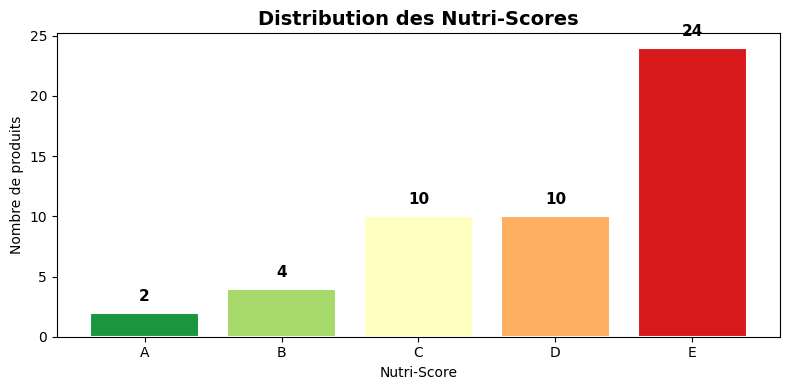

In [8]:
import matplotlib.pyplot as plt

# Distribution des Nutri-Scores
if 'nutriscore_grade' in df.columns:
    nutri_counts = df['nutriscore_grade'].str.upper().value_counts().reindex(
        ['A', 'B', 'C', 'D', 'E'], fill_value=0
    )
    colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

    plt.figure(figsize=(8, 4))
    bars = plt.bar(nutri_counts.index, nutri_counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, nutri_counts.values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
                 ha='center', fontsize=11, fontweight='bold')
    plt.title('Distribution des Nutri-Scores', fontsize=14, fontweight='bold')
    plt.xlabel('Nutri-Score')
    plt.ylabel('Nombre de produits')
    plt.tight_layout()
    plt.show()
else:
    print('Colonne nutriscore_grade non disponible dans ce DataFrame.')

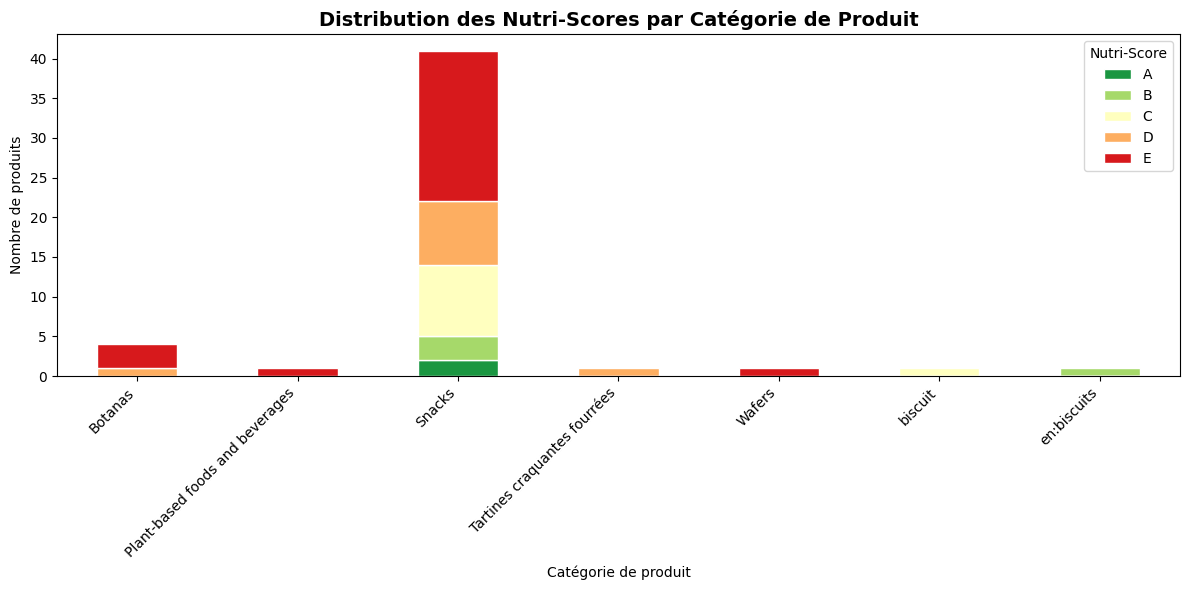

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DISTRIBUTION NUTRI-SCORE PAR CATEGORIE
# ==========================================

# vérifier colonnes
if 'nutriscore_grade' in df.columns and 'categories' in df.columns:

    # nettoyer données
    temp_df = df[['categories', 'nutriscore_grade']].dropna()

    temp_df['nutriscore_grade'] = temp_df['nutriscore_grade'].str.upper()

    # garder catégorie principale seulement
    temp_df['main_category'] = temp_df['categories'].apply(
        lambda x: x.split(',')[0] if isinstance(x, str) else x
    )

    # top catégories
    top_categories = temp_df['main_category'].value_counts().head(10).index

    temp_df = temp_df[temp_df['main_category'].isin(top_categories)]

    # tableau croisé
    nutri_category = pd.crosstab(
        temp_df['main_category'],
        temp_df['nutriscore_grade']
    )

    # ordre scores
    nutri_category = nutri_category.reindex(
        columns=['A', 'B', 'C', 'D', 'E'],
        fill_value=0
    )

    # couleurs nutri-score
    colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

    # ==========================================
    # PLOT
    # ==========================================

    ax = nutri_category.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='white'
    )

    plt.title(
        'Distribution des Nutri-Scores par Catégorie de Produit',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel('Catégorie de produit')

    plt.ylabel('Nombre de produits')

    plt.xticks(rotation=45, ha='right')

    plt.legend(title='Nutri-Score')

    plt.tight_layout()

    plt.show()

else:
    print("Colonnes 'categories' ou 'nutriscore_grade' non disponibles.")

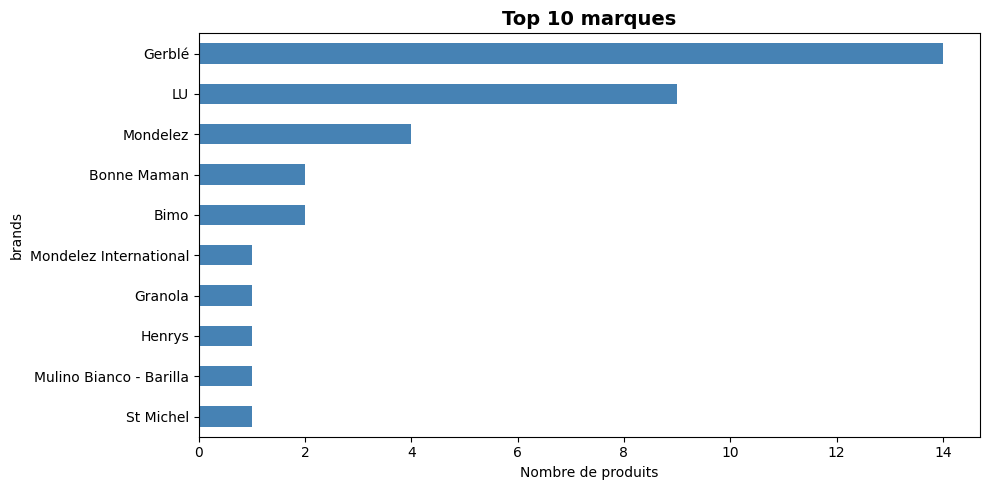

In [9]:
# Top 10 marques les plus représentées
if 'brands' in df.columns:
    top_brands = (
        df['brands']
        .dropna()
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
        .head(10)
    )
    plt.figure(figsize=(10, 5))
    top_brands.sort_values().plot(kind='barh', color='steelblue')
    plt.title('Top 10 marques', fontsize=14, fontweight='bold')
    plt.xlabel('Nombre de produits')
    plt.tight_layout()
    plt.show()
else:
    print('Colonne brands non disponible dans ce DataFrame.')

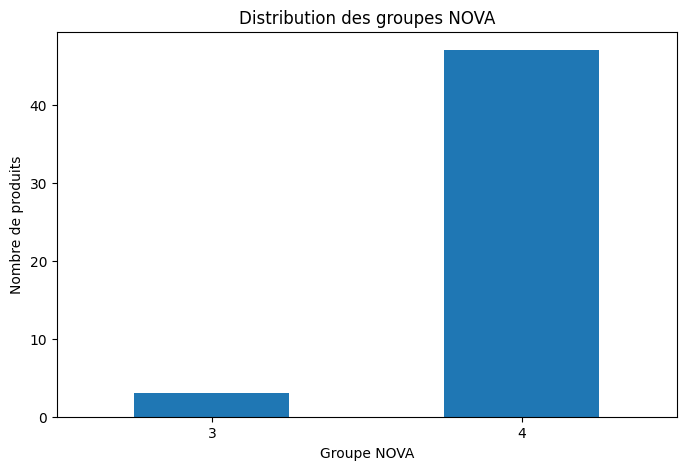

In [10]:
import matplotlib.pyplot as plt

# Distribution NOVA
if 'nova_group' in df.columns:
    nova_counts = df['nova_group'].value_counts().sort_index()

    plt.figure(figsize=(8,5))
    nova_counts.plot(kind='bar')

    plt.title('Distribution des groupes NOVA')
    plt.xlabel('Groupe NOVA')
    plt.ylabel('Nombre de produits')
    plt.xticks(rotation=0)

    plt.show()

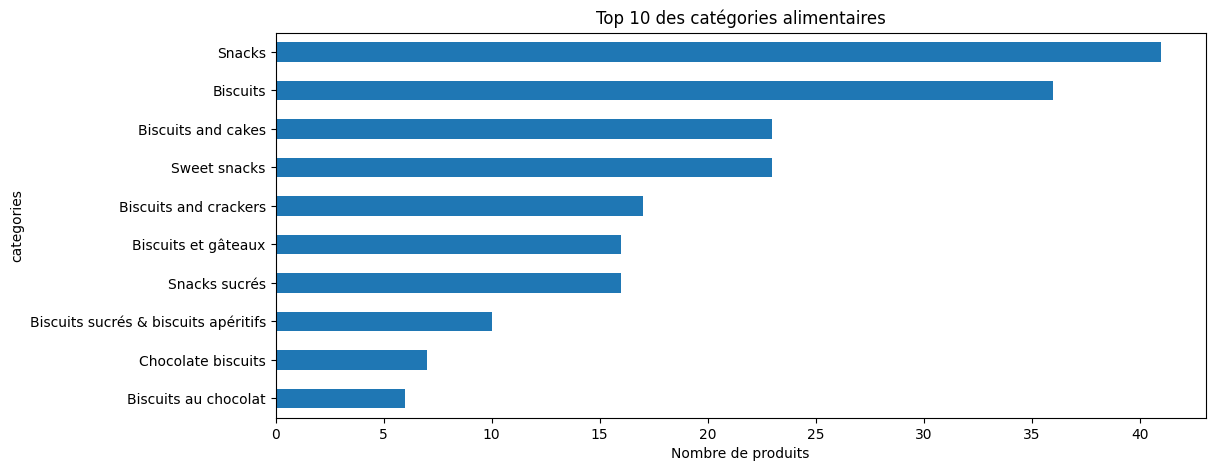

In [11]:
# Top catégories
if 'categories' in df.columns:
    top_categories = (
        df['categories']
        .dropna()
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(12,5))
    top_categories.sort_values().plot(kind='barh')

    plt.title('Top 10 des catégories alimentaires')
    plt.xlabel('Nombre de produits')

    plt.show()

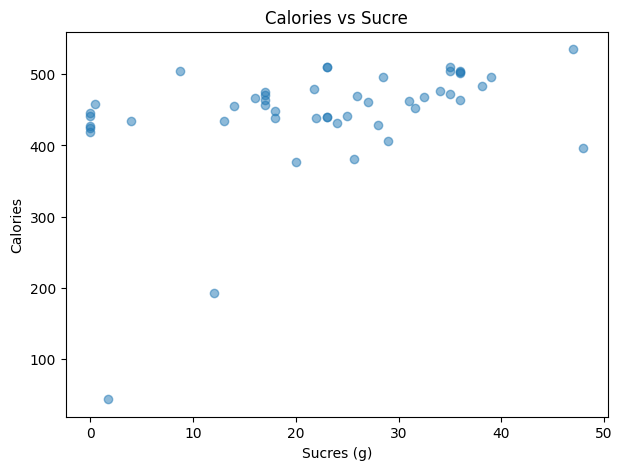

In [12]:
# Calories vs sucre
if 'energy-kcal_100g' in df.columns and 'sugars_100g' in df.columns:

    temp = df[['energy-kcal_100g', 'sugars_100g']].dropna()

    plt.figure(figsize=(7,5))

    plt.scatter(
        temp['sugars_100g'],
        temp['energy-kcal_100g'],
        alpha=0.5
    )

    plt.title('Calories vs Sucre')
    plt.xlabel('Sucres (g)')
    plt.ylabel('Calories')

    plt.show()

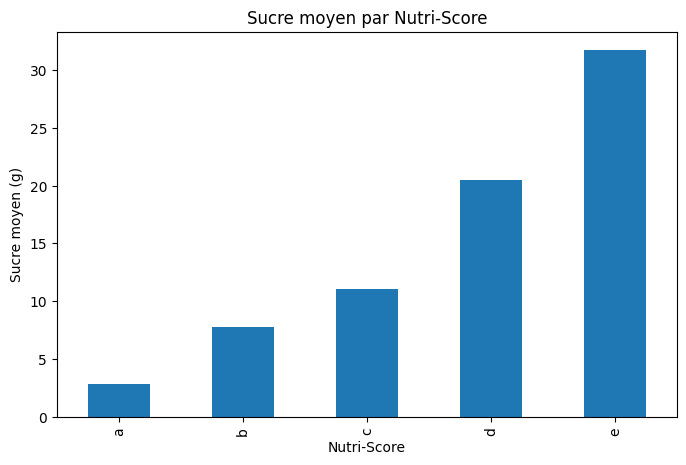

In [13]:
# Sucre moyen par Nutri-Score
if 'nutriscore_grade' in df.columns and 'sugars_100g' in df.columns:

    sugar_by_nutri = (
        df.groupby('nutriscore_grade')['sugars_100g']
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(8,5))

    sugar_by_nutri.plot(kind='bar')

    plt.title('Sucre moyen par Nutri-Score')
    plt.xlabel('Nutri-Score')
    plt.ylabel('Sucre moyen (g)')

    plt.show()

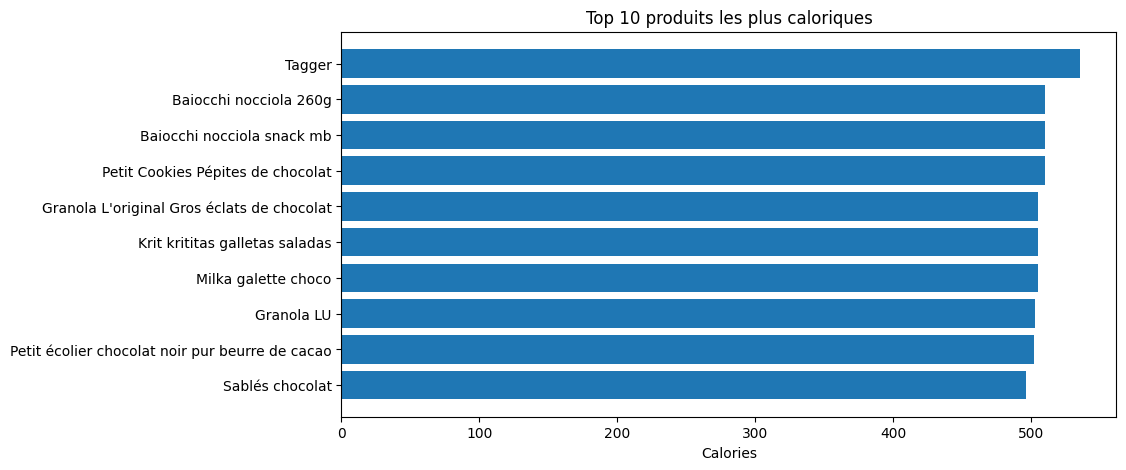

In [14]:
# Top produits caloriques
if 'product_name' in df.columns and 'energy-kcal_100g' in df.columns:

    top_calories = (
        df[['product_name', 'energy-kcal_100g']]
        .dropna()
        .sort_values(by='energy-kcal_100g', ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,5))

    plt.barh(
        top_calories['product_name'],
        top_calories['energy-kcal_100g']
    )

    plt.title('Top 10 produits les plus caloriques')
    plt.xlabel('Calories')

    plt.gca().invert_yaxis()

    plt.show()

In [15]:
# Export CSV — compatible Colab ET environnement local
output_path = 'openfoodfacts_resultats.csv'

df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'✅ Fichier sauvegardé : {output_path}')
print(f'   {len(df):,} lignes  |  {os.path.getsize(output_path) / 1024:.1f} Ko')

# Téléchargement depuis Google Colab (ignoré si exécuté hors Colab)
try:
    from google.colab import files
    files.download(output_path)
except ImportError:
    print('ℹ️ Exécution hors Colab — le fichier est sauvegardé localement.')

✅ Fichier sauvegardé : openfoodfacts_resultats.csv
   50 lignes  |  32.4 Ko


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# ---------------------------------------------------------------
# PARTIE 2 — Version finale corrigée
# ---------------------------------------------------------------

import requests
import pandas as pd
import os
import time
from IPython.display import display

BASE_MEALDB = "https://www.themealdb.com/api/json/v1/1"

df_off = pd.read_csv('openfoodfacts_resultats.csv', encoding='utf-8-sig')

# Termes garantis d'avoir des résultats sur MealDB
MOTS_GARANTIS = [
    'cake', 'cookie', 'chocolate', 'dessert',
    'bread', 'pudding', 'tart', 'muffin', 'pie'
]
print(f"✅ Termes de recherche : {MOTS_GARANTIS}")

✅ Termes de recherche : ['cake', 'cookie', 'chocolate', 'dessert', 'bread', 'pudding', 'tart', 'muffin', 'pie']


In [62]:
def search_mealdb(query: str) -> list:
    try:
        r = requests.get(f"{BASE_MEALDB}/search.php", params={'s': query}, timeout=15)
        r.raise_for_status()
        return r.json().get('meals') or []
    except Exception as e:
        print(f"  Erreur '{query}': {e}")
        return []

def search_mealdb_by_category(category: str) -> list:
    """Recherche par catégorie MealDB — plus de résultats."""
    try:
        r = requests.get(f"{BASE_MEALDB}/filter.php", params={'c': category}, timeout=15)
        r.raise_for_status()
        return r.json().get('meals') or []
    except Exception as e:
        print(f"  Erreur catégorie '{category}': {e}")
        return []

def get_meal_detail(meal_id: str) -> dict:
    """Récupère les détails complets (ingrédients) d'une recette."""
    try:
        r = requests.get(f"{BASE_MEALDB}/lookup.php", params={'i': meal_id}, timeout=15)
        r.raise_for_status()
        meals = r.json().get('meals') or []
        return meals[0] if meals else {}
    except:
        return {}

def get_ingredients(meal: dict) -> list:
    ingredients = []
    for i in range(1, 21):
        ing    = (meal.get(f'strIngredient{i}') or '').strip()
        mesure = (meal.get(f'strMeasure{i}')    or '').strip()
        if ing:
            ingredients.append(f"{mesure} {ing}".strip())
    return ingredients

In [63]:
# --- Collecte via catégorie Dessert (garantit ~60 recettes) + recherche par mot ---

all_meals = []
seen_ids  = set()

# 1) Catégorie Dessert complète
print("📂 Catégorie : Dessert")
minis = search_mealdb_by_category('Dessert')
print(f"   → {len(minis)} recettes trouvées, récupération des détails...")

for mini in minis[:40]:   # max 40 pour ne pas surcharger
    mid = mini.get('idMeal')
    if mid in seen_ids:
        continue
    seen_ids.add(mid)
    detail = get_meal_detail(mid)
    if detail:
        all_meals.append({
            'titre'      : detail.get('strMeal'),
            'categorie'  : detail.get('strCategory'),
            'cuisine'    : detail.get('strArea'),
            'tags'       : detail.get('strTags'),
            'ingredients': ', '.join(get_ingredients(detail)),
            'url'        : detail.get('strSource') or f"https://www.themealdb.com/meal/{mid}",
        })
    time.sleep(0.3)

print(f"   ✅ {len(all_meals)} recettes avec détails")

# 2) Recherche par mot-clé pour élargir
for mot in MOTS_GARANTIS:
    meals = search_mealdb(mot)
    for m in meals:
        mid = m.get('idMeal')
        if mid in seen_ids:
            continue
        seen_ids.add(mid)
        all_meals.append({
            'titre'      : m.get('strMeal'),
            'categorie'  : m.get('strCategory'),
            'cuisine'    : m.get('strArea'),
            'tags'       : m.get('strTags'),
            'ingredients': ', '.join(get_ingredients(m)),
            'url'        : m.get('strSource') or f"https://www.themealdb.com/meal/{m.get('idMeal')}",
        })
    time.sleep(0.3)

df_recettes = pd.DataFrame(all_meals).drop_duplicates(subset='titre').reset_index(drop=True)
print(f"\n✅ {len(df_recettes)} recettes uniques au total")
display(df_recettes[['titre', 'categorie', 'cuisine', 'ingredients']].head(10))

📂 Catégorie : Dessert
   → 129 recettes trouvées, récupération des détails...
   ✅ 40 recettes avec détails

✅ 113 recettes uniques au total


,titre,categorie,cuisine,ingredients
0,Æbleskiver,Dessert,Norway,"2 cups Flour, 1 teaspoon Salt, 2 tblsp Granula..."
1,Alfajores,Dessert,Argentina,"300g All purpose flour, 200g Cornstarch, 200g ..."
2,Anzac biscuits,Dessert,Australian,"85g Porridge oats, 85g Desiccated Coconut, 100..."
3,Apam balik,Dessert,Malaysian,"200ml Milk, 60ml Oil, 2 Eggs, 1600g Flour, 3 t..."
4,Apple & Blackberry Crumble,Dessert,British,"120g Plain Flour, 60g Caster Sugar, 60g Butter..."
5,Apple cake,Dessert,Netherlands,"4 Eggs, 200g Sugar, 200g Self-raising Flour, 2..."
6,Apple Frangipan Tart,Dessert,British,"175g/6oz digestive biscuits, 75g/3oz butter, 2..."
7,Apricot & Turkish delight mess,Dessert,Turkish,"100g Mascarpone, 50g Greek Yogurt, 25g Icing S..."
8,Arnhemse meisjes,Dessert,None,"5 Slices Puff Pastry, 100g vanilla sugar, 1/2 ..."
9,Authentic Norwegian Kransekake,Dessert,Norway,"3 Cups Almonds, 4 Egg White, 4 cups Powdered S..."


In [64]:
# ---------------------------------------------------------------
# Recommandation : match ingrédients ↔ produits OpenFoodFacts
# ---------------------------------------------------------------

# Construire la liste des ingrédients clés depuis les noms produits OFF
noms_produits = (
    df_off['product_name']
    .dropna()
    .str.lower()
    .str.replace(r'[^a-zàâéèêëîïôùûüç ]', '', regex=True)
    .str.strip()
    .unique()
)

# Extraire les mots significatifs (>3 lettres)
mots_produits = set()
for nom in noms_produits:
    for mot in nom.split():
        if len(mot) > 3:
            mots_produits.add(mot)

print(f"🔑 {len(mots_produits)} mots-clés extraits des produits OFF")

def score_recette(row: pd.Series) -> float:
    """
    Score basé sur le nombre de mots produits OFF
    présents dans les ingrédients de la recette.
    """
    texte = str(row.get('ingredients', '')).lower()
    matches = sum(1 for mot in mots_produits if mot in texte)
    # Normaliser sur 10 pour lisibilité
    return round(min(matches, 10) / 10, 3)

df_recettes['score'] = df_recettes.apply(score_recette, axis=1)

recommandations = (
    df_recettes
    .sort_values('score', ascending=False)
    .head(10)
    [['titre', 'categorie', 'cuisine', 'score', 'ingredients', 'url']]
    .reset_index(drop=True)
)

print("\n🏆 TOP 10 RECETTES RECOMMANDÉES")
display(recommandations)

🔑 99 mots-clés extraits des produits OFF

🏆 TOP 10 RECETTES RECOMMANDÉES


,titre,categorie,cuisine,score,ingredients,url
0,Chocolate churros with chocolate & salted cara...,Dessert,Spanish,0.6,"For frying Sunflower Oil, To serve Ice Cream, ...",https://www.bbcgoodfood.com/recipes/chocolate-...
1,Pistachio Kunafa Chocolate Cake and Cupcakes,Dessert,Saudi Arabian,0.6,"6 tablespoons White Chocolate, 1 cup Unsalted ...",https://cookpad.com/eng/recipes/25116037?ref=s...
2,Chocolate alfajores,Dessert,Uruguayan,0.5,"150g Butter, 70g Sugar, 1 Egg, 25g Honey, 175g...",https://jennyisbaking.com/2018/07/02/alfajores...
3,Hot Chocolate Fudge,Dessert,United States,0.5,"2 cups Chocolate Chips, 2 tbs Heavy Cream, 1 –...",https://www.themealdb.com/meal/52787
4,Choc Chip Pecan Pie,Dessert,United States,0.5,"300g Plain Flour, 75g Butter, 100g Cream Chees...",https://www.bbcgoodfood.com/recipes/choc-chip-...
5,Polish chocolate & walnut cake,Dessert,Polish,0.5,"150g Plain Flour, 50g Coco Sugar, 8 Egg, 200g ...",https://www.bbcgoodfood.com/recipes/polish-cho...
6,Chocolate Raspberry Brownies,Dessert,United States,0.4,"200g Dark Chocolate, 100g Milk Chocolate, 250g...",https://www.bbcgoodfood.com/recipes/2121648/be...
7,Chocolate Coconut Squares,Dessert,Australian,0.4,"100g Butter, 100g Caster Sugar, 2 Egg, 140g Se...",https://www.bbcgoodfood.com/recipes/isaacs-cho...
8,Christmas Pudding Trifle,Dessert,British,0.4,"3 Orange, 1 tbs Demerara Sugar, 2 tbs Grand Ma...",https://www.bbcgoodfood.com/recipes/1826685/ch...
9,Salted Caramel Cheescake,Dessert,United States,0.4,"250g Digestive Biscuits, 75g Pretzels, 135g Bu...",http://www.janespatisserie.com/2015/11/09/no-b...


In [65]:
# Export
output = 'mealdb_recommandations.csv'
df_recettes.to_csv(output, index=False, encoding='utf-8-sig')
print(f"✅ {output} — {len(df_recettes)} lignes | {os.path.getsize(output)/1024:.1f} Ko")

try:
    from google.colab import files
    files.download(output)
except ImportError:
    print("ℹ️ Fichier sauvegardé localement.")

✅ mealdb_recommandations.csv — 113 lignes | 33.1 Ko


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
# ---------------------------------------------------------------
# PARTIE 3 — Recherche de recettes par ingrédients
# ---------------------------------------------------------------

def rechercher_par_ingredients(ingredients_saisis: list) -> pd.DataFrame:
    """
    Pour chaque ingrédient saisi, interroge MealDB.
    Retourne les recettes qui contiennent LE PLUS d'ingrédients demandés.
    """
    resultats = {}  # id_meal -> {infos + nb_matches}

    for ingredient in ingredients_saisis:
        ingredient = ingredient.strip().lower()
        try:
            r = requests.get(f"{BASE_MEALDB}/filter.php",
                             params={'i': ingredient}, timeout=15)
            r.raise_for_status()
            meals = r.json().get('meals') or []

            for m in meals:
                mid = m.get('idMeal')
                if mid not in resultats:
                    resultats[mid] = {
                        'idMeal'   : mid,
                        'titre'    : m.get('strMeal'),
                        'image'    : m.get('strMealThumb'),
                        'matches'  : 0,
                        'ingredients_trouves': []
                    }
                resultats[mid]['matches'] += 1
                resultats[mid]['ingredients_trouves'].append(ingredient)

        except Exception as e:
            print(f"  Erreur pour '{ingredient}': {e}")

    if not resultats:
        return pd.DataFrame()

    # Trier par nombre de matches décroissant
    df = pd.DataFrame(resultats.values())
    df = df.sort_values('matches', ascending=False).reset_index(drop=True)
    return df


def afficher_recette(meal_id: str):
    """Affiche les détails complets d'une recette."""
    detail = get_meal_detail(meal_id)
    if not detail:
        print("Recette introuvable.")
        return

    print(f"\n{'='*55}")
    print(f"🍽️  {detail.get('strMeal')}")
    print(f"{'='*55}")
    print(f"📂 Catégorie : {detail.get('strCategory')}  |  🌍 Cuisine : {detail.get('strArea')}")
    print(f"🔗 {detail.get('strSource') or 'https://www.themealdb.com/meal/' + meal_id}")
    print(f"\n📝 Ingrédients :")
    for ing in get_ingredients(detail):
        print(f"   • {ing}")
    print(f"\n👨‍🍳 Instructions (début) :")
    instructions = (detail.get('strInstructions') or '').strip()
    print(instructions[:600] + ('...' if len(instructions) > 600 else ''))
    print(f"{'='*55}\n")

In [68]:
# ---------------------------------------------------------------
# Interface utilisateur — saisie ingrédients
# ---------------------------------------------------------------

print("🥘 RECHERCHE DE RECETTES PAR INGRÉDIENTS")
print("─" * 45)
saisie = input("Entrez vos ingrédients (séparés par des virgules) : ")

ingredients = [i.strip() for i in saisie.split(',') if i.strip()]

if not ingredients:
    print("⚠️  Aucun ingrédient saisi.")
else:
    print(f"\n🔍 Recherche avec : {ingredients}")
    df_results = rechercher_par_ingredients(ingredients)

    if df_results.empty:
        print("😕 Aucune recette trouvée avec ces ingrédients. Essayez en anglais (ex: chocolate, egg, flour).")
    else:
        nb_total = len(df_results)
        # Garder les recettes avec au moins 1 match
        df_top = df_results.head(5)

        print(f"\n✅ {nb_total} recette(s) trouvée(s) — Top {len(df_top)} :\n")
        for i, row in df_top.iterrows():
            found = ', '.join(row['ingredients_trouves'])
            print(f"  {i+1}. {row['titre']}  (✔ {row['matches']}/{len(ingredients)} ingrédient(s) : {found})")

        print()
        choix = input(f"Afficher le détail d'une recette ? Entrez un numéro (1-{len(df_top)}) ou 'non' : ")

        if choix.isdigit() and 1 <= int(choix) <= len(df_top):
            meal_id = df_top.iloc[int(choix) - 1]['idMeal']
            afficher_recette(meal_id)
        else:
            print("OK, bonne dégustation ! 🍴")

🥘 RECHERCHE DE RECETTES PAR INGRÉDIENTS
─────────────────────────────────────────────
Entrez vos ingrédients (séparés par des virgules) : egg

🔍 Recherche avec : ['egg']

✅ 91 recette(s) trouvée(s) — Top 5 :

  1. Æbleskiver  (✔ 1/1 ingrédient(s) : egg)
  2. Apple Potato Mash (Hete bliksem)   (✔ 1/1 ingrédient(s) : egg)
  3. Barbecue pork buns  (✔ 1/1 ingrédient(s) : egg)
  4. Beef Lo Mein  (✔ 1/1 ingrédient(s) : egg)
  5. Beetroot latkes  (✔ 1/1 ingrédient(s) : egg)

Afficher le détail d'une recette ? Entrez un numéro (1-5) ou 'non' : 1

🍽️  Æbleskiver
📂 Catégorie : Dessert  |  🌍 Cuisine : Norway
🔗 https://scandinaviancookbook.com/aebleskiver-danish-pancake-balls/

📝 Ingrédients :
   • 2 cups Flour
   • 1 teaspoon Salt
   • 2 tblsp Granulated Sugar
   • 1 teaspoon Baking Powder
   • 1/2 teaspoon Cardamom
   • 3 Egg
   • 2 cups Buttermilk
   • For Greasing Butter
   • Sprinkling Powdered Sugar
   • 1 scoop Raspberry Jam

👨‍🍳 Instructions (début) :
Whisk the flour, salt, sugar, baking s